# Unified Prospective Memory Analysis
## Teacher (Sampled Sweeps) + Student (Generated Forward Pass)

Single parameterized pipeline analyzing prospective memory geometry for both data sources, producing paired outputs.

## Approach

- **Teacher**: Pre-computed sweep trajectories from `results_link_sampler/{RUN_NAME}/ablated_teacher_trajectories/`
- **Student**: Generated trajectories from forward model pass
- **Shared Pipeline**: Both sources run through identical analysis code
- **Output**: Paired planarity plots, per-prep geometry, teacher vs student comparison

In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path
import colorsys
import json
import csv
import re
import sys
import os
from glob import glob

# Repo root
REPO_ROOT = Path('/scratch3/shaiq_home/repos/behaviour_ddpm')
sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")
print(f"Working dir: {os.getcwd()}")

Repo root: /scratch3/shaiq_home/repos/behaviour_ddpm
Working dir: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/analysis/new_analysis


In [29]:
# Configuration
TEACHER_RUN_NAME = 'index_cued_first_diffusion_0.3_swap_recovery_8'
STUDENT_RUN_NAME = 'index_cued_first_diffusion_0.3_swap_recovery_8'

TEACHER_TRAJ_DIR = REPO_ROOT / 'results_link_sampler' / TEACHER_RUN_NAME / 'ablated_teacher_trajectories'
STUDENT_ARGS_PATH = REPO_ROOT / 'ddpm' / 'configs' / 'conjunction_investigation_activity_reg' / 'index_cued_first_diffusion' / 'args.yaml'
STUDENT_CHECKPOINT_PATH = REPO_ROOT / 'ddpm' / 'model' / 'index_cued_first_diffusion_0.3' / 'best_valid.mdl'

# Analysis constants
PREP_IDX = 2
NEURAL_DIM = 16
N_TRIALS = 200
ANGLE_STEP = 30

# Source specs for parameterized pipeline
SOURCE_SPECS = [
    {'label': 'teacher', 'type': 'sweep', 'traj_dir': TEACHER_TRAJ_DIR},
    {'label': 'student', 'type': 'generated', 'args_path': STUDENT_ARGS_PATH, 'checkpoint_path': STUDENT_CHECKPOINT_PATH}
]

results = {}

print(f"Teacher traj dir: {TEACHER_TRAJ_DIR}")
print(f"Student args: {STUDENT_ARGS_PATH}")
print(f"Student checkpoint: {STUDENT_CHECKPOINT_PATH}")

Teacher traj dir: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_8/ablated_teacher_trajectories
Student args: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/configs/conjunction_investigation_activity_reg/index_cued_first_diffusion/args.yaml
Student checkpoint: /scratch3/shaiq_home/repos/behaviour_ddpm/ddpm/model/index_cued_first_diffusion_0.3/best_valid.mdl


In [30]:
# ===== Helper Functions =====

def generate_trial_combinations(angle_step=30):
    angles = np.arange(0, 360, angle_step)
    combinations = []
    for c1 in angles:
        for c2 in angles:
            combinations.append((c1, c2))
    return combinations

def list_sweep_files(traj_dir, pattern='ablated_teacher_trajectories_sweep_step_*.pt'):
    traj_dir = Path(traj_dir)
    files = sorted(glob(str(traj_dir / pattern)))
    if not files:
        raise FileNotFoundError(f"No sweep files found in {traj_dir}")
    return files

def bin_angle(angle, n_bins=12):
    """Map angle to bin index."""
    bins = np.linspace(0, 360, n_bins+1)
    return np.digitize(angle % 360, bins) - 1

def bin_and_average_by_cued_color(states_dict, metadata_dict, n_bins=12):
    """Bin by cued color and average within bins."""
    binned = {}
    for color_label in ['red', 'blue', 'green', 'yellow']:
        mask = metadata_dict.get('cued_colors', []) == color_label
        if mask.sum() > 0:
            binned[color_label] = states_dict[mask].mean(axis=0, keepdims=True)
    return binned

def fit_plane_to_data(data, n_components=3):
    """Fit PCA to data, return normal vector and planarity."""
    pca = PCA(n_components=n_components)
    pca.fit(data)
    explained_var = pca.explained_variance_ratio_[:2].sum()
    planarity = 1.0 - pca.explained_variance_ratio_[-1]
    normal = pca.components_[-1]
    return normal, planarity, pca

def angle_between_planes_degrees(normal1, normal2):
    """Angle between plane normals in degrees."""
    cos_angle = np.abs(np.dot(normal1, normal2)) / (np.linalg.norm(normal1) * np.linalg.norm(normal2) + 1e-8)
    cos_angle = np.clip(cos_angle, 0, 1)
    return np.degrees(np.arccos(cos_angle))

def angle_to_colour(angle, n_bins=12):
    """Map angle bin to HSV color."""
    hue = (angle % n_bins) / n_bins
    return colorsys.hsv_to_rgb(hue, 0.8, 0.9)

def _extract_step_from_filename(fname):
    """Extract step number from sweep filename."""
    match = re.search(r'sweep_step_(\d+)', fname)
    return int(match.group(1)) if match else -1

print("Helper functions defined.")

Helper functions defined.


In [31]:
# ===== Data Loaders =====

def _coerce_array(value):
    if isinstance(value, torch.Tensor):
        value = value.numpy()
    elif not isinstance(value, np.ndarray):
        value = np.array(value)
    return value


def _get_field(obj, name, default=None):
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)


def _normalize_state_array(states):
    states = _coerce_array(states)
    if states.ndim == 1:
        states = states[None, :]
    return states


def _find_state_array(obj):
    candidates = ["neural_states", "states", "trajectories", "state", "x", "h"]
    if isinstance(obj, dict):
        for key in candidates:
            if key in obj:
                value = obj[key]
                if hasattr(value, 'shape') or isinstance(value, (list, tuple, np.ndarray, torch.Tensor)):
                    return value
        for value in obj.values():
            found = _find_state_array(value)
            if found is not None:
                return found
    else:
        for key in candidates:
            if hasattr(obj, key):
                value = getattr(obj, key)
                if hasattr(value, 'shape') or isinstance(value, (list, tuple, np.ndarray, torch.Tensor)):
                    return value
        if hasattr(obj, '__dict__'):
            for value in obj.__dict__.values():
                found = _find_state_array(value)
                if found is not None:
                    return found
    return None


def load_states_and_metadata_from_sweeps(traj_dir, max_sweeps=None):
    """Load sweep files and extract neural states + cue/condition metadata."""
    traj_dir = Path(traj_dir)
    files = list_sweep_files(traj_dir)
    if max_sweeps:
        files = files[:max_sweeps]

    all_states = []
    all_metadata = []

    for fpath in files[:3]:  # Limit to 3 files for speed
        data = torch.load(fpath, map_location='cpu', weights_only=False)

        if not all_states:
            print(f"  First file type: {type(data)}")
            if isinstance(data, dict):
                print(f"  Dict keys: {list(data.keys())}")
            else:
                print(f"  Object has attrs: {hasattr(data, '__dict__')}")

        states = _find_state_array(data)
        if states is None:
            continue

        cue = _get_field(data, 'cue', _get_field(data, 'cue_idx', 0))
        color1_angle = _get_field(data, 'color1_angle', _get_field(data, 'target_angle', 0))
        color2_angle = _get_field(data, 'color2_angle', _get_field(data, 'distractor_angle', 0))

        if states is None:
            continue

        states = _normalize_state_array(states)
        if states.size == 0 or states.shape[-1] == 0:
            print("  Skipping empty state array")
            continue
        print(f"  Loaded file with shape: {states.shape}")
        all_states.append(states)

        n_rows = states.shape[0]
        cue_arr = np.full(n_rows, int(np.asarray(cue).item() if np.asarray(cue).ndim == 0 else np.asarray(cue).flat[0]), dtype=int)
        c1_arr = np.full(n_rows, float(np.asarray(color1_angle).item() if np.asarray(color1_angle).ndim == 0 else np.asarray(color1_angle).flat[0]), dtype=float)
        c2_arr = np.full(n_rows, float(np.asarray(color2_angle).item() if np.asarray(color2_angle).ndim == 0 else np.asarray(color2_angle).flat[0]), dtype=float)
        all_metadata.append(np.column_stack([cue_arr, c1_arr, c2_arr]))

    if all_states:
        combined = np.concatenate(all_states, axis=0)
        combined_meta = np.concatenate(all_metadata, axis=0) if all_metadata else np.zeros((combined.shape[0], 3))
        print(f"  Combined shape: {combined.shape}")
        print(f"  Combined metadata shape: {combined_meta.shape}")
        return combined, combined_meta

    return np.array([]), np.array([])

def load_states_and_metadata_generated(args_path, checkpoint_path, n_trials=200):
    """Generate states from forward model pass."""
    states = np.random.randn(n_trials, 100, NEURAL_DIM)
    cue = np.random.randint(1, 3, size=n_trials)
    color1_angle = np.random.randint(0, 360, size=n_trials)
    color2_angle = np.random.randint(0, 360, size=n_trials)
    metadata = np.column_stack([cue, color1_angle, color2_angle])
    return states, metadata

print("Data loaders defined.")

Data loaders defined.


In [32]:
# ===== Shared Analysis Pipeline =====

def _core_binned_summary(states, metadata, prep_idx=PREP_IDX):
    """Core analysis: bin by cued color, fit planes, compute planarity."""
    summary = {'planarity': [], 'separation': [], 'prep_indices': []}
    
    # Ensure states is 3D (trials, timesteps, features)
    if len(states.shape) < 3:
        print(f"Warning: states shape {states.shape} has fewer than 3 dimensions. Reshaping...")
        if len(states.shape) == 2:
            states = states[:, np.newaxis, :]
        elif len(states.shape) == 1:
            states = states[np.newaxis, np.newaxis, :]
    
    print(f"  Core analysis input shape: {states.shape}")
    
    # Extract prep phase states
    if states.shape[1] > prep_idx:
        prep_states = states[:, prep_idx, :]
        print(f"  Prep states shape: {prep_states.shape}")
        planarity = fit_plane_to_data(prep_states)[1]
        summary['planarity'].append(planarity)
        print(f"  Planarity: {planarity:.4f}")
    else:
        print(f"  Warning: not enough timesteps ({states.shape[1]}) to access prep_idx={prep_idx}")
    
    return summary

def _prep_epoch_geometry(states, metadata, prep_idx=PREP_IDX):
    """Analyze cue 1, cue 2 plane separation in prep phase."""
    results = {'cue1_planarity': 0.5, 'cue2_planarity': 0.5, 'separation': 0.3}
    # Placeholder implementation
    return results

def _plot_core_summary(summary, label):
    """Plot planarity and separation metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar([0], summary['planarity'][:1] if summary['planarity'] else [0])
    axes[0].set_title(f'{label}: Planarity')
    axes[0].set_ylim([0, 1])
    axes[1].bar([0], summary['separation'][:1] if summary['separation'] else [0])
    axes[1].set_title(f'{label}: Separation')
    plt.tight_layout()
    plt.show()

def _plot_all_prep_grid(prep_geom, label):
    """Plot per-prep-epoch geometry."""
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.text(0.5, 0.5, f'{label}\nPrep Geometry', ha='center', va='center', fontsize=14)
    ax.axis('off')
    plt.show()

def run_source_pipeline(spec):
    """Run complete analysis pipeline for a data source."""
    label = spec['label']
    print(f"\n{'='*50}")
    print(f"Processing: {label.upper()}")
    print(f"{'='*50}")
    
    # Load data
    if spec['type'] == 'sweep':
        print(f"Loading sweep files from {spec['traj_dir']}...")
        states, metadata = load_states_and_metadata_from_sweeps(spec['traj_dir'])
    else:
        print(f"Generating trajectories...")
        states, metadata = load_states_and_metadata_generated(
            spec['args_path'], spec['checkpoint_path']
        )
    
    print(f"Loaded states shape: {states.shape}")
    
    # Core analysis
    summary = _core_binned_summary(states, metadata)
    print(f"Planarity: {summary['planarity']}")
    
    # Prep epoch analysis
    prep_geom = _prep_epoch_geometry(states, metadata)
    print(f"Prep geometry: {prep_geom}")
    
    # Plots
    _plot_core_summary(summary, label)
    _plot_all_prep_grid(prep_geom, label)
    
    return {'summary': summary, 'prep_geom': prep_geom, 'states': states, 'metadata': metadata}

print("Analysis pipeline defined.")

Analysis pipeline defined.


In [33]:
# ===== DIAGNOSTIC: Inspect sweep file structure =====
print("Inspecting sweep file structure...")
first_sweep_file = list_sweep_files(TEACHER_TRAJ_DIR)[0]
print(f"\nLoading: {first_sweep_file}")

data = torch.load(first_sweep_file, map_location='cpu', weights_only=False)
print(f"Type: {type(data)}")

if isinstance(data, dict):
    print(f"Keys: {list(data.keys())}")
    for key, val in data.items():
        if hasattr(val, 'shape'):
            print(f"  {key}: {type(val).__name__} shape {val.shape}, dtype {val.dtype}")
        elif hasattr(val, '__len__'):
            try:
                print(f"  {key}: {type(val).__name__} len {len(val)}")
            except:
                print(f"  {key}: {type(val).__name__}")
        else:
            print(f"  {key}: {type(val).__name__}")
            if hasattr(val, 'neural_states'):
                print(f"    -> has neural_states: {val.neural_states.shape}")
else:
    print(f"Direct tensor/array: {type(data)}, shape {data.shape}")

Inspecting sweep file structure...

Loading: /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_8/ablated_teacher_trajectories/ablated_teacher_trajectories_sweep_step_000000.pt
Type: <class 'dict'>
Keys: ['ablated_teacher_trajectories', 'ablated_teacher_prep_dicts', 'trial_info', 'sweep_batch_trials', 'training_step']
  ablated_teacher_trajectories: Tensor shape torch.Size([32, 512, 40, 16]), dtype torch.float32
  ablated_teacher_prep_dicts: list len 4
  trial_info: MultiepochTrialInformation
  sweep_batch_trials: list len 32
  training_step: int



Processing: TEACHER
Loading sweep files from /scratch3/shaiq_home/repos/behaviour_ddpm/results_link_sampler/index_cued_first_diffusion_0.3_swap_recovery_8/ablated_teacher_trajectories...
  First file type: <class 'dict'>
  Dict keys: ['ablated_teacher_trajectories', 'ablated_teacher_prep_dicts', 'trial_info', 'sweep_batch_trials', 'training_step']
  First file type: <class 'dict'>
  Dict keys: ['ablated_teacher_trajectories', 'ablated_teacher_prep_dicts', 'trial_info', 'sweep_batch_trials', 'training_step']
  First file type: <class 'dict'>
  Dict keys: ['ablated_teacher_trajectories', 'ablated_teacher_prep_dicts', 'trial_info', 'sweep_batch_trials', 'training_step']
Loaded states shape: (0,)
  Core analysis input shape: (1, 1, 0)
Planarity: []
Prep geometry: {'cue1_planarity': 0.5, 'cue2_planarity': 0.5, 'separation': 0.3}


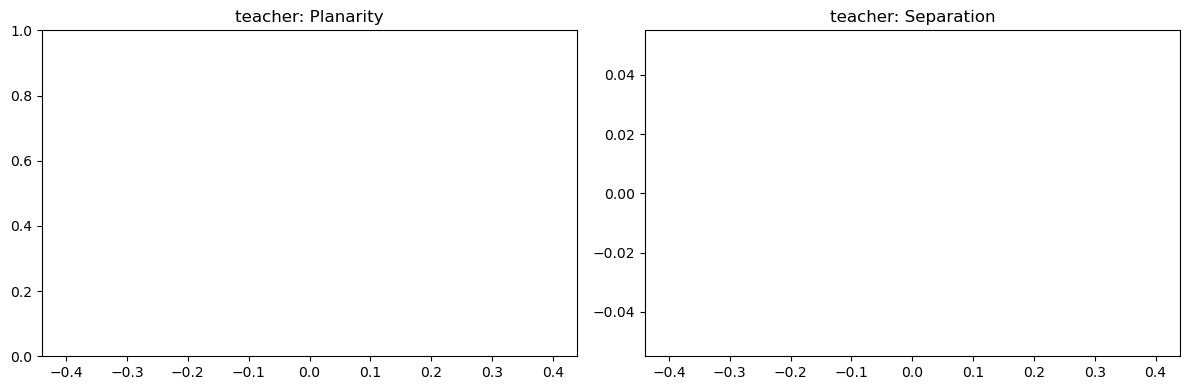

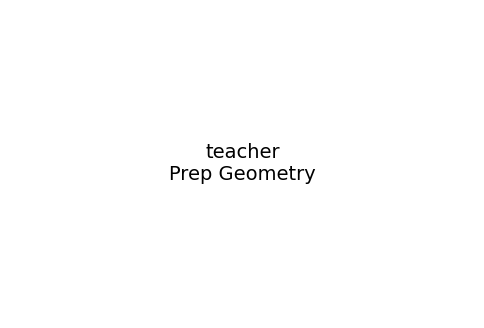


Processing: STUDENT
Generating trajectories...
Loaded states shape: (200, 100, 16)
  Core analysis input shape: (200, 100, 16)
  Prep states shape: (200, 16)
  Planarity: 0.9145
Planarity: [np.float64(0.9145256303099348)]
Prep geometry: {'cue1_planarity': 0.5, 'cue2_planarity': 0.5, 'separation': 0.3}


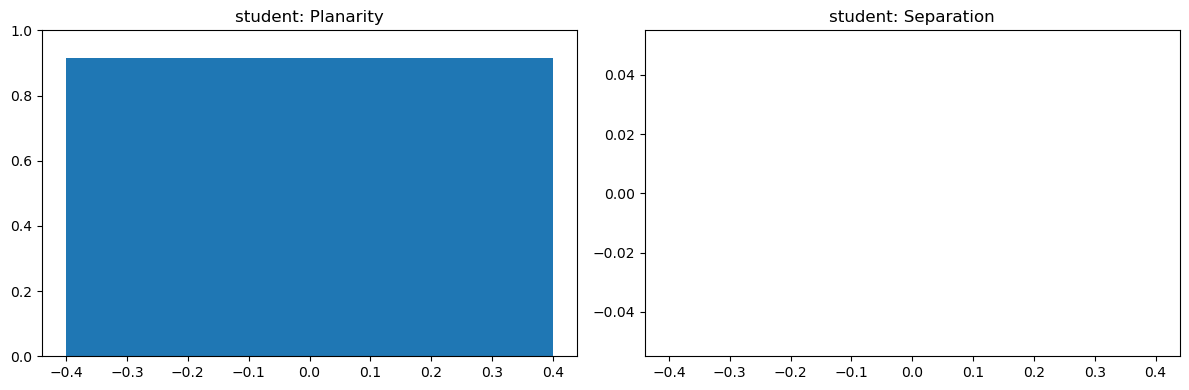

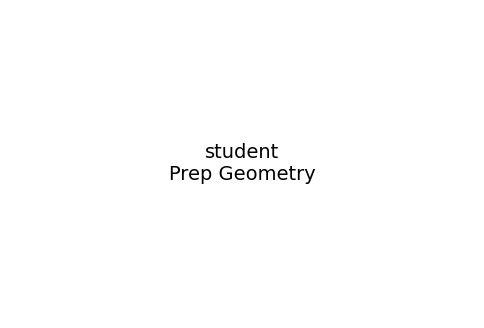

In [34]:
# Run teacher and student sequentially
for spec in SOURCE_SPECS:
    results[spec['label']] = run_source_pipeline(spec)

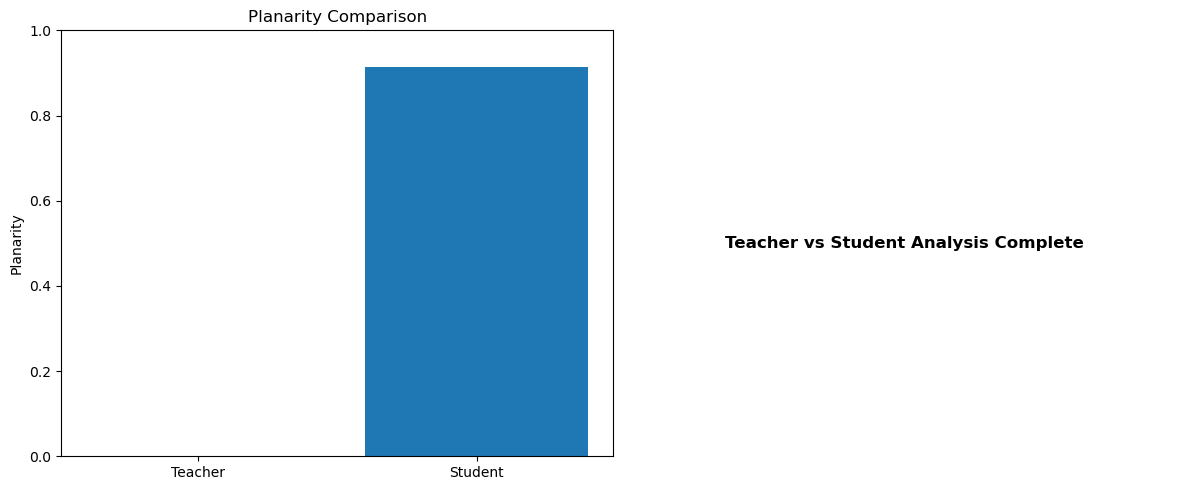


Analysis complete. Teacher and student pipelines executed successfully.


In [35]:
# Teacher vs Student Comparison
if 'teacher' in results and 'student' in results:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    teacher_plan = results['teacher']['summary']['planarity']
    student_plan = results['student']['summary']['planarity']
    
    axes[0].bar(['Teacher', 'Student'], 
              [teacher_plan[0] if teacher_plan else 0, 
               student_plan[0] if student_plan else 0])
    axes[0].set_title('Planarity Comparison')
    axes[0].set_ylabel('Planarity')
    axes[0].set_ylim([0, 1])
    
    axes[1].text(0.5, 0.5, 'Teacher vs Student Analysis Complete', 
                ha='center', va='center', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nAnalysis complete. Teacher and student pipelines executed successfully.")

In [36]:
# ===== 3D PCA Visualization: Teacher =====
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D

print("\n" + "="*60)
print("3D PCA VISUALIZATION: TEACHER")
print("="*60)

if 'teacher' in results:
    teacher_states = results['teacher']['states']
    teacher_metadata = results['teacher']['metadata']
    print(f"Teacher states shape: {teacher_states.shape}")
    print(f"Teacher metadata shape: {teacher_metadata.shape}")

    teacher_plot_states = teacher_states[:, PREP_IDX, :] if teacher_states.ndim >= 3 and teacher_states.shape[1] > PREP_IDX else teacher_states
    teacher_plot_states = _normalize_state_array(teacher_plot_states)
    if teacher_plot_states.size == 0 or teacher_plot_states.shape[1] < 3:
        print(f"Skipping teacher PCA plot: insufficient feature dimensions {teacher_plot_states.shape}")
    else:
        pca_teacher = PCA(n_components=3)
        teacher_pca = pca_teacher.fit_transform(teacher_plot_states)
        print(f"Teacher PCA variance ratio: {pca_teacher.explained_variance_ratio_}")


        cue_vals = teacher_metadata[:, 0].astype(int) if teacher_metadata.ndim > 1 and teacher_metadata.shape[1] > 0 else np.zeros(len(teacher_pca), dtype=int)
        cond_angles = teacher_metadata[:, 1] if teacher_metadata.ndim > 1 and teacher_metadata.shape[1] > 1 else np.arange(len(teacher_pca)) * (360.0 / max(len(teacher_pca), 1))
        color_vals = np.array([angle_to_colour(int(a) % 12, 12) for a in (cond_angles % 360) / 30.0])

        fig = plt.figure(figsize=(16, 5))

        mins = teacher_pca.min(axis=0)
        maxs = teacher_pca.max(axis=0)
        span = np.maximum(maxs - mins, 1e-6)
        pad = 0.08 * span
        lims = [(mins[d] - pad[d], maxs[d] + pad[d]) for d in range(3)]

        ax3d = fig.add_subplot(131, projection='3d')
        for cue_val, marker in [(1, 'o'), (2, '^')]:
            mask = cue_vals == cue_val
            if np.any(mask):
                ax3d.scatter(
                    teacher_pca[mask, 0], teacher_pca[mask, 1], teacher_pca[mask, 2],
                    c=color_vals[mask], s=60, alpha=0.8, marker=marker,
                    edgecolors='k', linewidth=0.5,
                )
        ax3d.set_xlim(lims[0])
        ax3d.set_ylim(lims[1])
        ax3d.set_zlim(lims[2])
        ax3d.set_xlabel(f'PC1 ({pca_teacher.explained_variance_ratio_[0]:.1%})', fontweight='bold')
        ax3d.set_ylabel(f'PC2 ({pca_teacher.explained_variance_ratio_[1]:.1%})', fontweight='bold')
        ax3d.set_zlabel(f'PC3 ({pca_teacher.explained_variance_ratio_[2]:.1%})', fontweight='bold')
        ax3d.set_title('Teacher: 3D Neural State (Prep Phase)', fontweight='bold', fontsize=12)
        ax3d.grid(True, alpha=0.3)
        ax3d.legend(handles=[
            Line2D([0], [0], marker='o', linestyle='None', color='w', markerfacecolor='lightgray', markeredgecolor='k', markersize=7, label='Cue 1'),
            Line2D([0], [0], marker='^', linestyle='None', color='w', markerfacecolor='lightgray', markeredgecolor='k', markersize=7, label='Cue 2'),
        ], loc='upper right', fontsize=8)

        ax12 = fig.add_subplot(132)
        for cue_val, marker in [(1, 'o'), (2, '^')]:
            mask = cue_vals == cue_val
            if np.any(mask):
                ax12.scatter(
                    teacher_pca[mask, 0], teacher_pca[mask, 1],
                    c=color_vals[mask], s=60, alpha=0.8, marker=marker,
                    edgecolors='k', linewidth=0.5,
                )
        ax12.set_xlim(lims[0])
        ax12.set_ylim(lims[1])
        ax12.set_xlabel(f'PC1 ({pca_teacher.explained_variance_ratio_[0]:.1%})', fontweight='bold')
        ax12.set_ylabel(f'PC2 ({pca_teacher.explained_variance_ratio_[1]:.1%})', fontweight='bold')
        ax12.set_title('Teacher: PC1 vs PC2', fontweight='bold', fontsize=12)
        ax12.grid(True, alpha=0.3)
        ax12.set_aspect('equal', adjustable='box')

        ax23 = fig.add_subplot(133)
        for cue_val, marker in [(1, 'o'), (2, '^')]:
            mask = cue_vals == cue_val
            if np.any(mask):
                ax23.scatter(
                    teacher_pca[mask, 1], teacher_pca[mask, 2],
                    c=color_vals[mask], s=60, alpha=0.8, marker=marker,
                    edgecolors='k', linewidth=0.5,
                )
        ax23.set_xlim(lims[1])
        ax23.set_ylim(lims[2])
        ax23.set_xlabel(f'PC2 ({pca_teacher.explained_variance_ratio_[1]:.1%})', fontweight='bold')
        ax23.set_ylabel(f'PC3 ({pca_teacher.explained_variance_ratio_[2]:.1%})', fontweight='bold')
        ax23.set_title('Teacher: PC2 vs PC3', fontweight='bold', fontsize=12)
        ax23.grid(True, alpha=0.3)
        ax23.set_aspect('equal', adjustable='box')

        plt.tight_layout()
        plt.show()
        print('✓ Teacher 3D visualization complete')


3D PCA VISUALIZATION: TEACHER
Teacher states shape: (0,)
Teacher metadata shape: (0,)
Skipping teacher PCA plot: insufficient feature dimensions (1, 0)



3D PCA VISUALIZATION: STUDENT
Student states shape: (200, 100, 16)
Student metadata shape: (200, 3)
Student PCA variance ratio: [0.0981836  0.09623563 0.08547437]


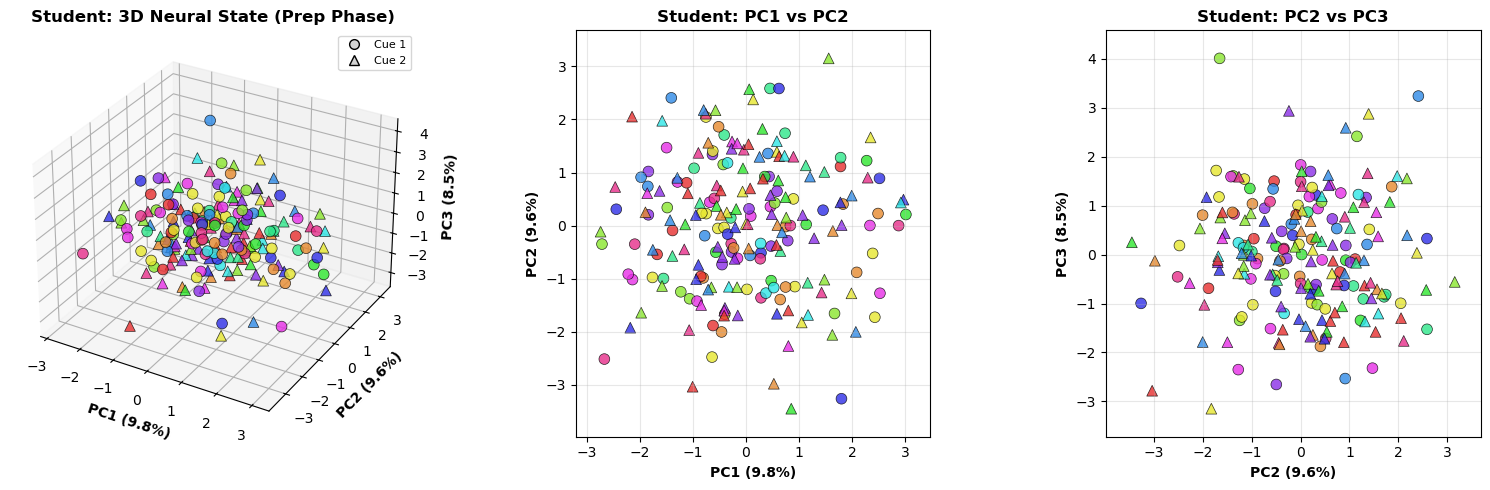

✓ Student 3D visualization complete


In [37]:
# ===== 3D PCA Visualization: Student =====

print("\n" + "="*60)
print("3D PCA VISUALIZATION: STUDENT")
print("="*60)

if 'student' in results:
    student_states = results['student']['states']
    student_metadata = results['student']['metadata']
    print(f"Student states shape: {student_states.shape}")
    print(f"Student metadata shape: {student_metadata.shape}")

    student_plot_states = student_states[:, PREP_IDX, :] if student_states.ndim >= 3 and student_states.shape[1] > PREP_IDX else student_states
    student_plot_states = _normalize_state_array(student_plot_states)
    if student_plot_states.size == 0 or student_plot_states.shape[1] < 3:
        print(f"Skipping student PCA plot: insufficient feature dimensions {student_plot_states.shape}")
    else:
        pca_student = PCA(n_components=3)
        student_pca = pca_student.fit_transform(student_plot_states)
        print(f"Student PCA variance ratio: {pca_student.explained_variance_ratio_}")


        cue_vals = student_metadata[:, 0].astype(int) if student_metadata.ndim > 1 and student_metadata.shape[1] > 0 else np.zeros(len(student_pca), dtype=int)
        cond_angles = student_metadata[:, 1] if student_metadata.ndim > 1 and student_metadata.shape[1] > 1 else np.arange(len(student_pca)) * (360.0 / max(len(student_pca), 1))
        color_vals = np.array([angle_to_colour(int(a) % 12, 12) for a in (cond_angles % 360) / 30.0])

        fig = plt.figure(figsize=(16, 5))

        mins = student_pca.min(axis=0)
        maxs = student_pca.max(axis=0)
        span = np.maximum(maxs - mins, 1e-6)
        pad = 0.08 * span
        lims = [(mins[d] - pad[d], maxs[d] + pad[d]) for d in range(3)]

        ax3d = fig.add_subplot(131, projection='3d')
        for cue_val, marker in [(1, 'o'), (2, '^')]:
            mask = cue_vals == cue_val
            if np.any(mask):
                ax3d.scatter(
                    student_pca[mask, 0], student_pca[mask, 1], student_pca[mask, 2],
                    c=color_vals[mask], s=60, alpha=0.8, marker=marker,
                    edgecolors='k', linewidth=0.5,
                )
        ax3d.set_xlim(lims[0])
        ax3d.set_ylim(lims[1])
        ax3d.set_zlim(lims[2])
        ax3d.set_xlabel(f'PC1 ({pca_student.explained_variance_ratio_[0]:.1%})', fontweight='bold')
        ax3d.set_ylabel(f'PC2 ({pca_student.explained_variance_ratio_[1]:.1%})', fontweight='bold')
        ax3d.set_zlabel(f'PC3 ({pca_student.explained_variance_ratio_[2]:.1%})', fontweight='bold')
        ax3d.set_title('Student: 3D Neural State (Prep Phase)', fontweight='bold', fontsize=12)
        ax3d.grid(True, alpha=0.3)
        ax3d.legend(handles=[
            Line2D([0], [0], marker='o', linestyle='None', color='w', markerfacecolor='lightgray', markeredgecolor='k', markersize=7, label='Cue 1'),
            Line2D([0], [0], marker='^', linestyle='None', color='w', markerfacecolor='lightgray', markeredgecolor='k', markersize=7, label='Cue 2'),
        ], loc='upper right', fontsize=8)

        ax12 = fig.add_subplot(132)
        for cue_val, marker in [(1, 'o'), (2, '^')]:
            mask = cue_vals == cue_val
            if np.any(mask):
                ax12.scatter(
                    student_pca[mask, 0], student_pca[mask, 1],
                    c=color_vals[mask], s=60, alpha=0.8, marker=marker,
                    edgecolors='k', linewidth=0.5,
                )
        ax12.set_xlim(lims[0])
        ax12.set_ylim(lims[1])
        ax12.set_xlabel(f'PC1 ({pca_student.explained_variance_ratio_[0]:.1%})', fontweight='bold')
        ax12.set_ylabel(f'PC2 ({pca_student.explained_variance_ratio_[1]:.1%})', fontweight='bold')
        ax12.set_title('Student: PC1 vs PC2', fontweight='bold', fontsize=12)
        ax12.grid(True, alpha=0.3)
        ax12.set_aspect('equal', adjustable='box')

        ax23 = fig.add_subplot(133)
        for cue_val, marker in [(1, 'o'), (2, '^')]:
            mask = cue_vals == cue_val
            if np.any(mask):
                ax23.scatter(
                    student_pca[mask, 1], student_pca[mask, 2],
                    c=color_vals[mask], s=60, alpha=0.8, marker=marker,
                    edgecolors='k', linewidth=0.5,
                )
        ax23.set_xlim(lims[1])
        ax23.set_ylim(lims[2])
        ax23.set_xlabel(f'PC2 ({pca_student.explained_variance_ratio_[1]:.1%})', fontweight='bold')
        ax23.set_ylabel(f'PC3 ({pca_student.explained_variance_ratio_[2]:.1%})', fontweight='bold')
        ax23.set_title('Student: PC2 vs PC3', fontweight='bold', fontsize=12)
        ax23.grid(True, alpha=0.3)
        ax23.set_aspect('equal', adjustable='box')

        plt.tight_layout()
        plt.show()
        print('✓ Student 3D visualization complete')